In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as plty
import plotly.express as px
import math
import geoip2.database
from user_agents import parse
import os

In [50]:
df = pd.read_csv("../data/raw/int/cybersecurity_attacks.csv")

In [51]:
# Total 40k rows
len(df)

40000

In [52]:
# Visualise first 5 rows
df.head(5)

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [53]:
df.columns

Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature',
       'Action Taken', 'Severity Level', 'User Information',
       'Device Information', 'Network Segment', 'Geo-location Data',
       'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source'],
      dtype='object')

In [54]:
# Total 25 columns
len(df.columns)

25

In [55]:
# Only 4 numerical columns, the rest are all objects
df.dtypes

Timestamp                  object
Source IP Address          object
Destination IP Address     object
Source Port                 int64
Destination Port            int64
Protocol                   object
Packet Length               int64
Packet Type                object
Traffic Type               object
Payload Data               object
Malware Indicators         object
Anomaly Scores            float64
Alerts/Warnings            object
Attack Type                object
Attack Signature           object
Action Taken               object
Severity Level             object
User Information           object
Device Information         object
Network Segment            object
Geo-location Data          object
Proxy Information          object
Firewall Logs              object
IDS/IPS Alerts             object
Log Source                 object
dtype: object

In [56]:
# Only 4 numerical columns:
# - No outliers detected
# - Mean and median are very close to each other
# - No anomaly detected, instead the quartiles seems to be well distributed
df.describe()

,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


In [57]:
# Unique values per column
df.nunique()

Timestamp                 39997
Source IP Address         40000
Destination IP Address    40000
Source Port               29761
Destination Port          29895
Protocol                      3
Packet Length              1437
Packet Type                   2
Traffic Type                  3
Payload Data              40000
Malware Indicators            1
Anomaly Scores             9826
Alerts/Warnings               1
Attack Type                   3
Attack Signature              2
Action Taken                  3
Severity Level                3
User Information          32389
Device Information        32104
Network Segment               3
Geo-location Data          8723
Proxy Information         20148
Firewall Logs                 1
IDS/IPS Alerts                1
Log Source                    2
dtype: int64

In [58]:
# Total 12 columns with more than 10 unique values - need further analysis (feature engineering?)
len(df.nunique()[df.nunique() > 10])

12

In [59]:
# 5 columns with missing values: Malware Indicators, Alerts/Warnings, Proxy Information, Firewall Logs, IDS/IPS Alerts
df.isna().sum()

Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Payload Data                  0
Malware Indicators        20000
Anomaly Scores                0
Alerts/Warnings           20067
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level                0
User Information              0
Device Information            0
Network Segment               0
Geo-location Data             0
Proxy Information         19851
Firewall Logs             19961
IDS/IPS Alerts            20050
Log Source                    0
dtype: int64

In [60]:
# Temporarily fill missing values for EDA purpose 
df['Malware Indicators'] = df['Malware Indicators'].fillna("no IoC Detected")
df['Alerts/Warnings'] = df['Alerts/Warnings'].fillna("no Alert Triggered")
df['Firewall Logs'] = df['Firewall Logs'].fillna("no Log Data")
df['IDS/IPS Alerts'] = df['IDS/IPS Alerts'].fillna("no Alert Data")

In [61]:
df

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,no Alert Data,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,no Alert Data,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,no Log Data,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,no Log Data,Alert Data,Firewall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,26.36.109.26,121.100.75.240,31005,6764,UDP,1428,Control,HTTP,Quibusdam ullam consequatur consequuntur accus...,...,Logged,Medium,Adira Madan,Mozilla/5.0 (iPad; CPU iPad OS 14_2_1 like Mac...,Segment A,"Nashik, Manipur",NaN,Log Data,Alert Data,Firewall
39996,2023-03-27 00:38:27,17.21.163.81,196.108.134.78,2553,28091,UDP,1184,Control,HTTP,Quaerat neque esse. Animi expedita natus commo...,...,Logged,High,Rati Dara,Mozilla/5.0 (Windows; U; Windows 98; Win 9x 4....,Segment C,"Vadodara, Mizoram",60.51.30.46,Log Data,no Alert Data,Firewall
39997,2022-03-31 01:45:49,162.35.217.57,98.107.0.15,22505,25152,UDP,1043,Data,DNS,Enim at aspernatur illum. Saepe numquam eligen...,...,Blocked,Low,Samiha Joshi,Mozilla/5.0 (Windows; U; Windows NT 4.0) Apple...,Segment C,"Mahbubnagar, Himachal Pradesh",NaN,Log Data,Alert Data,Server
39998,2023-09-22 18:32:38,208.72.233.205,173.79.112.252,20013,2703,UDP,483,Data,FTP,Officiis dolorem sed harum provident earum dis...,...,Ignored,Low,Rasha Chauhan,Mozilla/5.0 (X11; Linux i686) AppleWebKit/536....,Segment B,"Rourkela, Arunachal Pradesh",137.76.130.8,Log Data,no Alert Data,Server


In [62]:
# Drop column(s) #1
# - User Information: name of users,  despite certains persons being attacked more than once (like 2-6 times),
# too less frequency and no logical link to the Attack Type
# - Payload Data: dummy contents, not useful for analysis
df = df.drop(columns=['User Information', 'Payload Data'])

In [63]:
df.head(10)

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,...,Attack Signature,Action Taken,Severity Level,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,IoC Detected,...,Known Pattern B,Logged,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,no Alert Data,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,IoC Detected,...,Known Pattern A,Blocked,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,no Alert Data,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,IoC Detected,...,Known Pattern B,Ignored,Low,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,no IoC Detected,...,Known Pattern B,Blocked,Medium,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,no Log Data,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,no IoC Detected,...,Known Pattern B,Blocked,Low,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,no Log Data,Alert Data,Firewall
5,2022-10-28 13:14:27,198.102.5.160,147.190.155.133,17430,52805,UDP,1423,Data,HTTP,no IoC Detected,...,Known Pattern A,Logged,Medium,Opera/8.58.(X11; Linux i686; nl-NL) Presto/2.9...,Segment C,"Aurangabad, Meghalaya",NaN,no Log Data,no Alert Data,Server
6,2022-05-16 17:55:43,97.253.103.59,77.16.101.53,26562,17416,TCP,379,Data,DNS,no IoC Detected,...,Known Pattern B,Ignored,High,Opera/9.24.(X11; Linux i686; fa-IR) Presto/2.9...,Segment A,"Eluru, Manipur",NaN,Log Data,no Alert Data,Server
7,2023-02-12 07:13:17,11.48.99.245,178.157.14.116,34489,20396,ICMP,1022,Data,DNS,IoC Detected,...,Known Pattern A,Logged,High,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_7_6...,Segment A,"Phagwara, Andhra Pradesh",192.31.159.5,Log Data,Alert Data,Firewall
8,2023-06-27 11:02:56,49.32.208.167,72.202.237.9,56296,20857,TCP,1281,Control,FTP,IoC Detected,...,Known Pattern A,Blocked,High,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_5_8...,Segment B,"Ambala, Tripura",NaN,Log Data,Alert Data,Server
9,2021-08-15 22:29:04,114.109.149.113,160.88.194.172,37918,50039,UDP,224,Data,HTTP,no IoC Detected,...,Known Pattern B,Blocked,Medium,Mozilla/5.0 (Windows; U; Windows NT 6.0) Apple...,Segment A,"Rampur, Mizoram",87.128.245.244,no Log Data,no Alert Data,Server


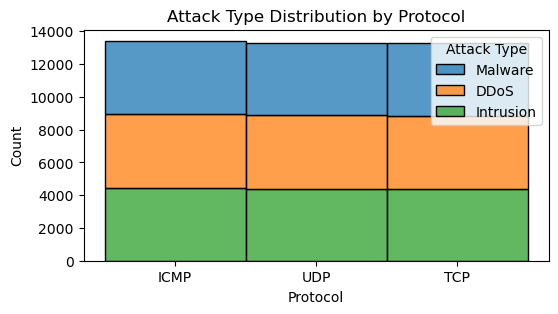

In [64]:
# Attack Type Distribution by Protocol => fair distribution of Attack Type across different Protocols
plt.figure(figsize=(6,3))
sns.histplot(x="Protocol", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Protocol")
plt.show()

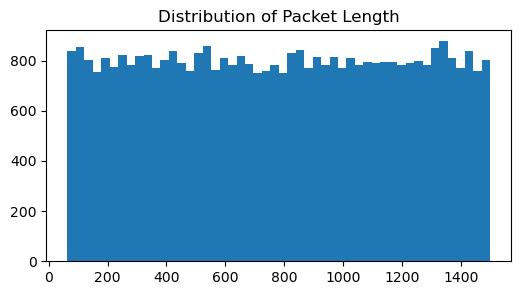

In [65]:
# Packet Length are spread evenly from 0 to 100
plt.figure(figsize=(6,3))
plt.hist(df['Packet Length'], bins=50)
plt.title("Distribution of Packet Length")
plt.show()

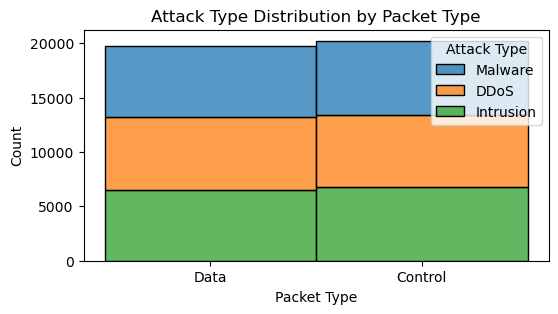

In [66]:
# Attack Type Distribution by Packet Type => fair distribution of Attack Type across different Protocols
plt.figure(figsize=(6,3))
sns.histplot(x="Packet Type", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Packet Type")
plt.show()

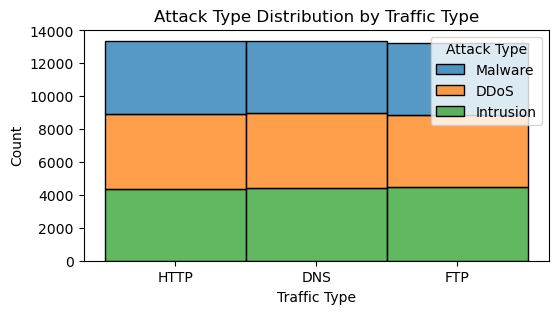

In [67]:
# Attack Type Distribution by Traffic Type => fair distribution of Attack Type across different Traffic Type
plt.figure(figsize=(6,3))
sns.histplot(x="Traffic Type", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Traffic Type")
plt.show()

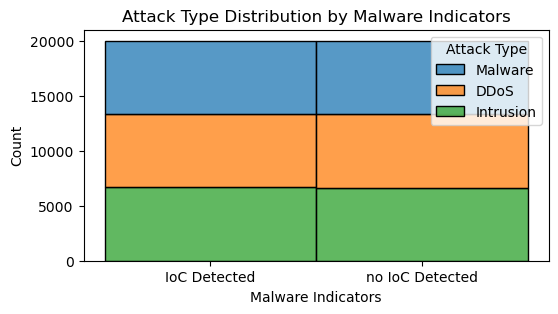

In [68]:
# Attack Type Distribution by Malware Indicators => fair distribution of Attack Type across different Malware Indicators
plt.figure(figsize=(6,3))
sns.histplot(x= "Malware Indicators", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Malware Indicators")
plt.show()

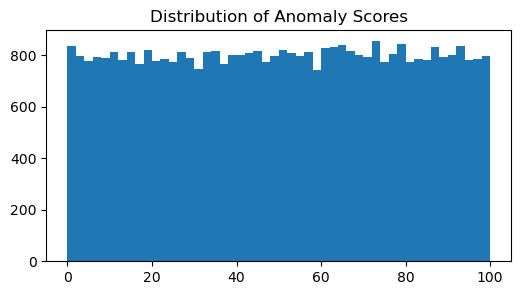

In [69]:
# Anomaly Scores are spread evenly from 0 to 100
plt.figure(figsize=(6,3))
plt.hist(df['Anomaly Scores'], bins=50)
plt.title("Distribution of Anomaly Scores")
plt.show()

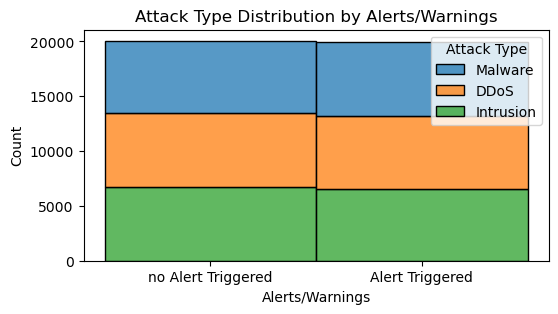

In [70]:
# Attack Type Distribution by Alerts/Warnings => fair distribution of Attack Type across different Alerts/Warnings
plt.figure(figsize=(6,3))
sns.histplot(x= "Alerts/Warnings", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Alerts/Warnings")
plt.show()

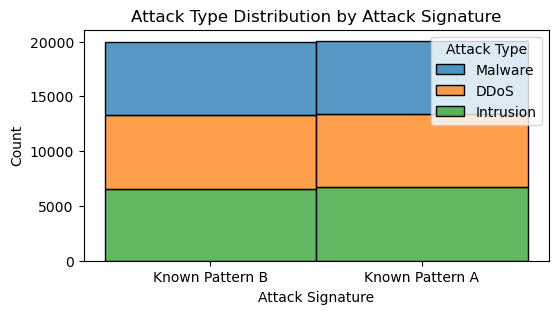

In [71]:
# Attack Type Distribution by Attack Signature => fair distribution of Attack Type across different Attack Signature
plt.figure(figsize=(6,3))
sns.histplot(x= "Attack Signature", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Attack Signature")
plt.show()

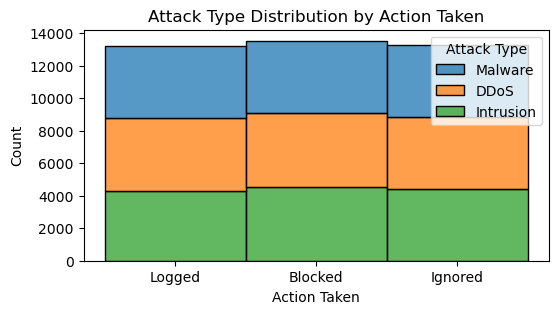

In [72]:
# Attack Type Distribution by Action Taken => fair distribution of Attack Type across different Action Taken
plt.figure(figsize=(6,3))
sns.histplot(x= "Action Taken", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Action Taken")
plt.show()

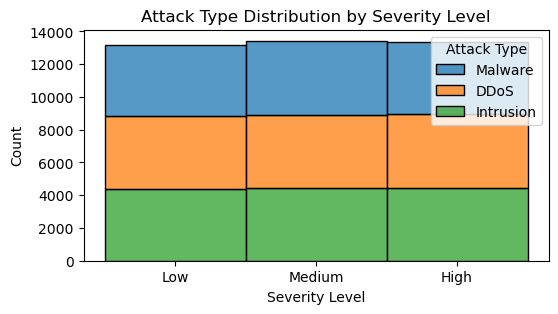

In [73]:
# Attack Type Distribution by Severity Levele => fair distribution of Attack Type across different Severity Level
plt.figure(figsize=(6,3))
sns.histplot(x= "Severity Level", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Severity Level")
plt.show()

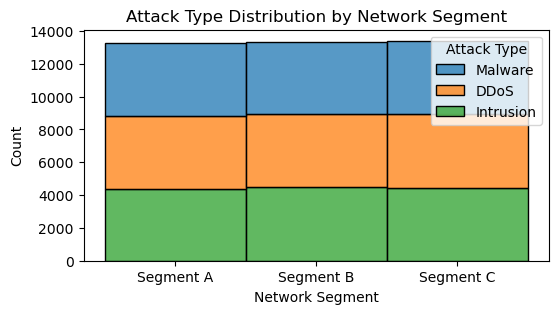

In [74]:
# Attack Type Distribution by Network Segment => fair distribution of Attack Type across different Network Segment
plt.figure(figsize=(6,3))
sns.histplot(x= "Network Segment", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Network Segment")
plt.show()

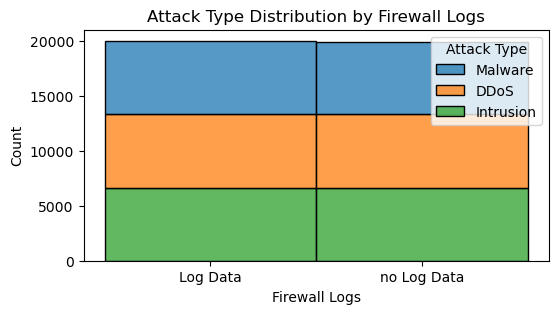

In [75]:
# Attack Type Distribution by Firewall Logs => fair distribution of Attack Type across different Firewall Logs
plt.figure(figsize=(6,3))
sns.histplot(x= "Firewall Logs", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Firewall Logs")
plt.show()

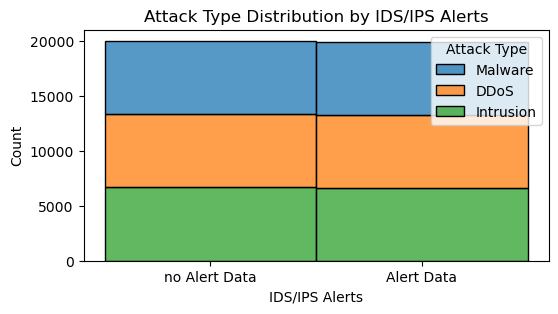

In [76]:
# Attack Type Distribution by IDS/IPS Alerts => fair distribution of Attack Type across different IDS/IPS Alerts
plt.figure(figsize=(6,3))
sns.histplot(x= "IDS/IPS Alerts", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by IDS/IPS Alerts")
plt.show()

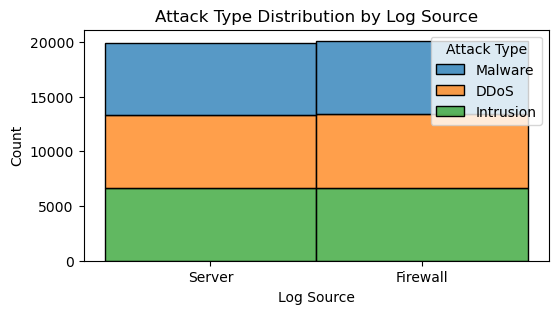

In [77]:
# Attack Type Distribution by Log Source => fair distribution of Attack Type across different Log Source
plt.figure(figsize=(6,3))
sns.histplot(x= "Log Source", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by Log Source")
plt.show()

In [78]:
df.columns

Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Malware Indicators', 'Anomaly Scores',
       'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken',
       'Severity Level', 'Device Information', 'Network Segment',
       'Geo-location Data', 'Proxy Information', 'Firewall Logs',
       'IDS/IPS Alerts', 'Log Source'],
      dtype='object')

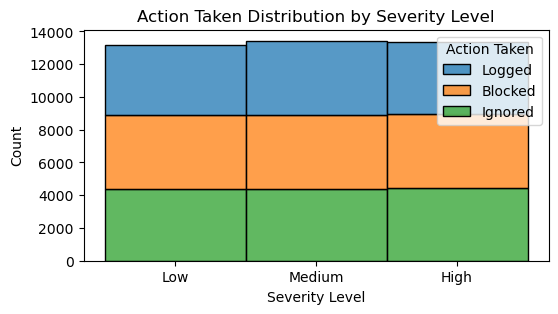

In [79]:
# Action Taken Distribution by Severity Level => fair distribution of Action Taken across different Severity Level.
# High severity level doesn't have more blocked actions.
plt.figure(figsize=(6,3))
sns.histplot(x="Severity Level",hue="Action Taken",multiple="stack",data=df)
plt.title("Action Taken Distribution by Severity Level")
plt.show()

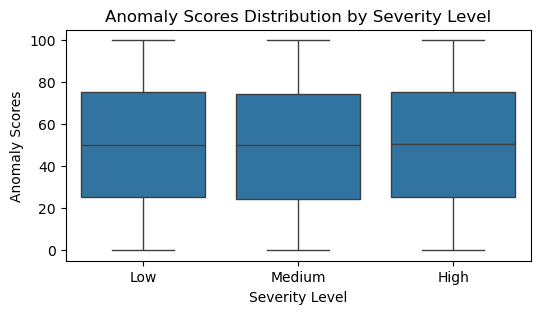

In [80]:
# Seems like no positive correlation between Severity Level and Anomaly Scores
# df.groupby('Severity Level')['Anomaly Scores'].describe()
plt.figure(figsize=(6,3))
sns.boxplot( x = "Severity Level", y = "Anomaly Scores", data = df)
plt.title("Anomaly Scores Distribution by Severity Level")
plt.show()

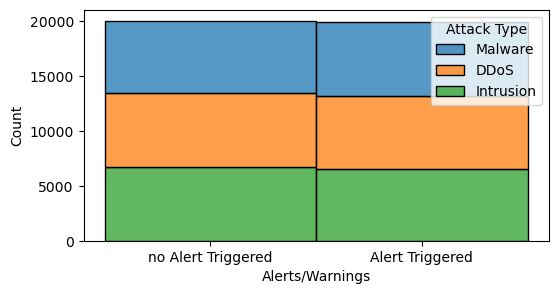

In [81]:
# Alerts/Warnings distribution by Attack Type => fair distribution of Attack Type across different Alerts/Warnings
plt.figure(figsize=(6,3))
sns.histplot(x = "Alerts/Warnings", hue = "Attack Type", multiple = "stack", data=df)
plt.show()

In [82]:
# pd.to_datetime(df.loc[0, ['Timestamp']]) # test first row of Timestamp with function to_datetime
# (pd.to_datetime(df.loc[0, ['Timestamp']])).dtypes # to check data type after to_datetime => n
# Convert Timestamp to datetime (if not already)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [83]:
# Group by Timestamp and Attack Type, then count occurrences
attack_counts = df.groupby(['Timestamp', 'Attack Type']).size().unstack(fill_value=0)

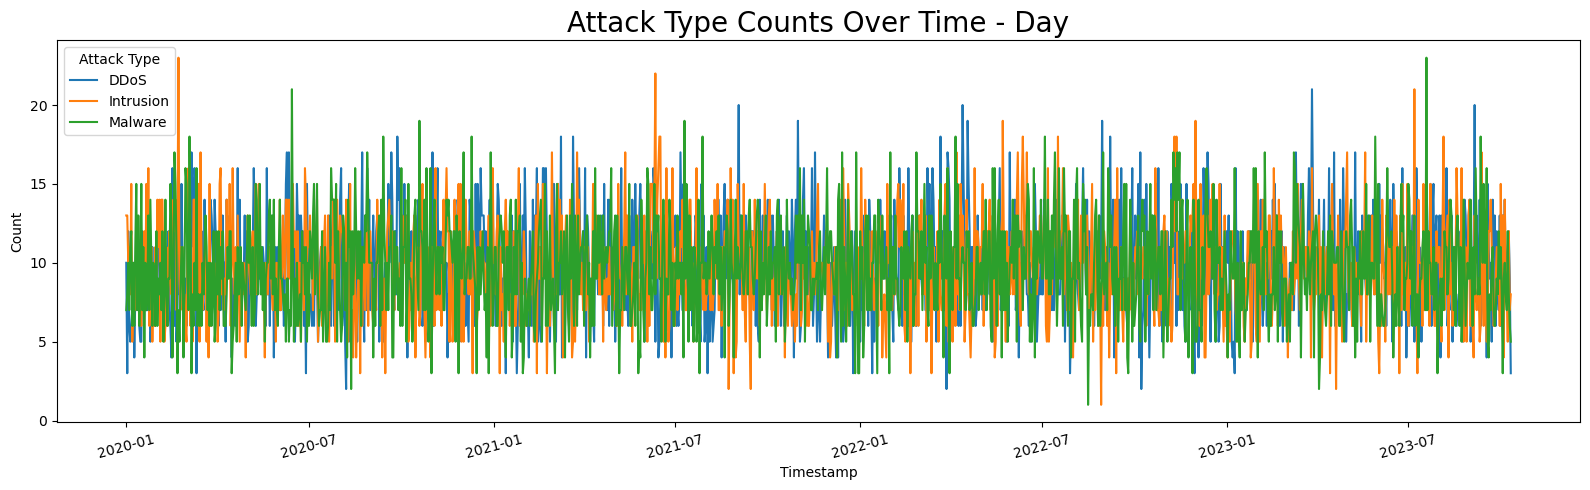

In [84]:
# Conclusion: fluctuatif but not easy to analyze the trend. Also logically, taking days might not logic for ML modeling purpose,
# cause days spread through total of 4 years. Also despite fluctuation, distribution seems fair across different Attack Types.
# Sample to daily trends
attack_counts_day = attack_counts.resample('D').sum()

# Plot
fig = plt.figure(figsize=(16, 5))
for col in attack_counts_day.columns:
    plt.plot(attack_counts_day.index, attack_counts_day[col], label=col)

plt.title('Attack Type Counts Over Time - Day', fontsize=20)
plt.xlabel('Timestamp', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.xticks(rotation=15, fontsize=10)
plt.legend(title='Attack Type', fontsize=10)
plt.tight_layout()
plt.show()

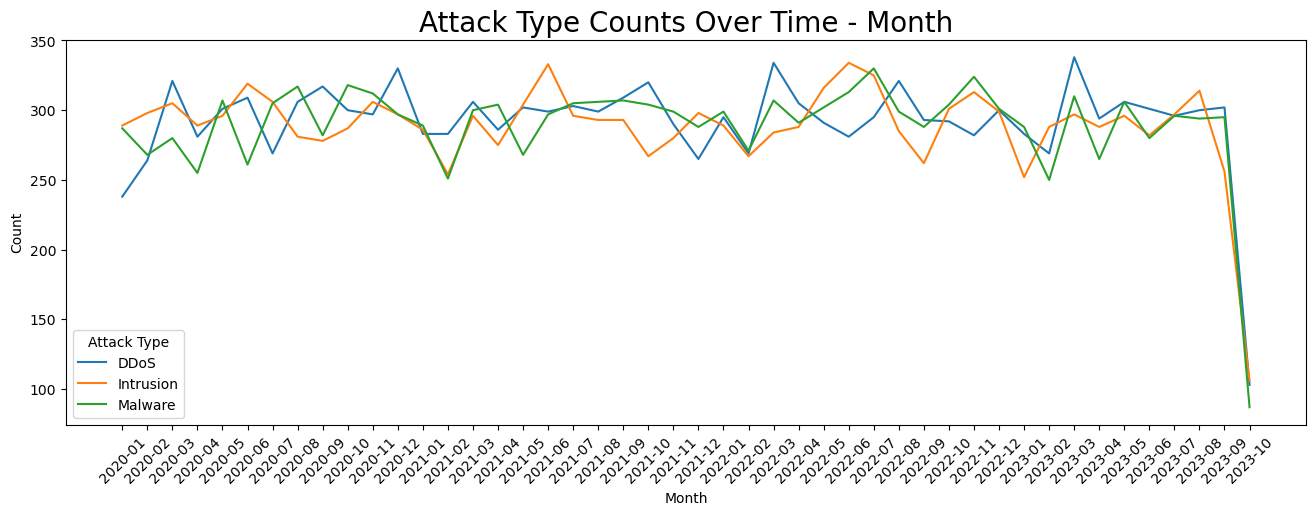

In [85]:
# Conclusion: fluctuatif but not easy to analyze the trend. Also logically, taking months might not logic for ML modeling purpose,
# cause months spread through total of 4 years. Also despite fluctuation, distribution seems fair across different Attack Types.

# Sample to monthly trends
attack_counts_month = attack_counts.resample('ME').sum()
months = attack_counts_month.index.strftime('%Y-%m')

fig = plt.figure(figsize=(16, 5))
for col in attack_counts_month.columns:
    plt.plot(months, attack_counts_month[col], label=col)
plt.title('Attack Type Counts Over Time - Month', fontsize=20)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.xticks(rotation=45, fontsize=10)
plt.legend(title='Attack Type', fontsize=10)
plt.show()

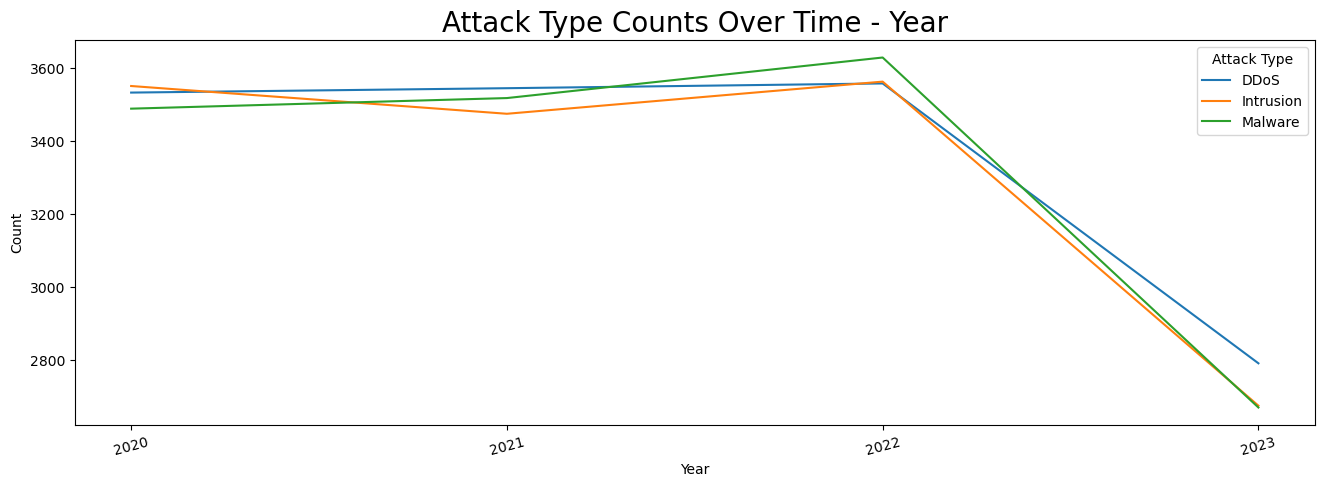

In [86]:
# Conclusion: Not logic to take year for ML modeling purpose cause only 4 data points and also each attack types show almost same frequency for each year
# Sample to yearly trends
attack_counts_year = attack_counts.resample('YE').sum()
years = attack_counts_year.index.year  # Extract years as integers

fig = plt.figure(figsize=(16, 5))
for col in attack_counts_year.columns:
    plt.plot(years, attack_counts_year[col], label=col)

plt.title('Attack Type Counts Over Time - Year', fontsize=20)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.xticks(years, rotation=15, fontsize=10)  # Show only unique years
plt.legend(title='Attack Type', fontsize=10)
plt.show()

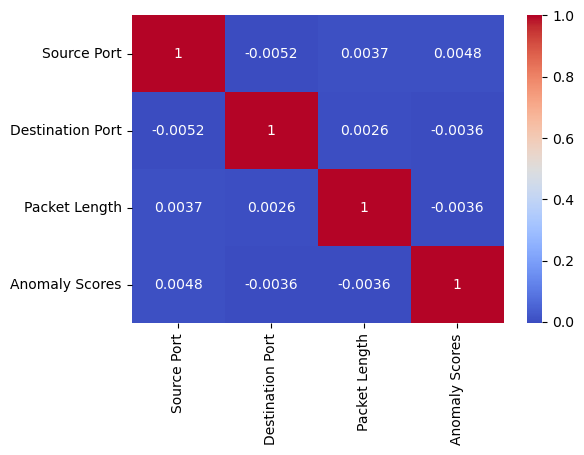

In [87]:
# Correlation heatmap for numerical columns #1-Fast check - not really useful for the moment, need more numerical features
# In any way, there seems no strong correlation between the four features (Source Port, Destination Port, Packet Length, Anomaly Scores)
plt.figure(figsize=(6,4))
numeric_cols_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols_df.corr(), annot = True, cmap='coolwarm')
plt.show()

In [88]:
# Save the processed df after first EDA
# Create processed_data directory if it doesn't exist
os.makedirs('../data/processed_data', exist_ok=True)

# Save as CSV
df.to_csv('../data/processed_data/cybersecurity_attacks_firstEDA.csv', index=False)
print("DataFrame saved as CSV!")

DataFrame saved as CSV!


In [90]:
df.isna().sum()

Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Malware Indicators            0
Anomaly Scores                0
Alerts/Warnings               0
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level                0
Device Information            0
Network Segment               0
Geo-location Data             0
Proxy Information         19851
Firewall Logs                 0
IDS/IPS Alerts                0
Log Source                    0
dtype: int64